In [1]:
!hostname

n22.clstr


In [1]:
import xarray as xr
import os
import glob
import geopandas as gpd
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import LogNorm
from matplotlib.colors import BoundaryNorm
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors

In [2]:
shapefile_path = "/center1/DYNDOWN/phutton5/ROS/boundaries/Alaska_Borough_and_Census_Area_Boundaries.shp"
borough_boundaries = gpd.read_file(shapefile_path)
borough_boundaries = borough_boundaries.set_crs(epsg=3338)
borough_boundaries = borough_boundaries.to_crs(epsg=4326)
FNSB_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Fairbanks North Star Borough']
FNSB_geom = FNSB_boundary.geometry.iloc[0] 
FNSB_coords = []
FNSB_coords.extend(list(FNSB_geom.exterior.coords))
FNSB_coords = np.array(FNSB_coords)  
FNSB_coords = pd.DataFrame({
    "lon": FNSB_coords[:, 0],
    "lat": FNSB_coords[:, 1]
})

Fairbanks_lat=(64.84)
Fairbanks_lon=(-147.72)

Mun_of_Anc_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Municipality of Anchorage']
Bethel_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Bethel Census Area']
Mat_Su_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Matanuska-Susitna Borough']
Denali_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Denali Borough']

In [26]:
path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/'
compare=f'ROS_Monthly_*.nc'
file_list = sorted(glob.glob(os.path.join(path, compare)))
combined_ds=xr.open_mfdataset(file_list, combine='by_coords',engine='netcdf4')

os.chdir("/import/beegfs/CMIP6/wrf_era5")
geo_em_path = "geo_em.d02.nc"
geo = xr.open_dataset(geo_em_path)
oceanmask=geo['LU_INDEX']
oceanmask=oceanmask.squeeze(dim='Time')
#oceanmask_expanded = oceanmask.expand_dims(Time=data.Time)

combined_ds = combined_ds.where(oceanmask != 17)
era5_4km=combined_ds

era54kmlat = combined_ds['XLAT'].values
era54kmlon = combined_ds['XLONG'].values

ROS_Tally_era5_4km=np.sum(era5_4km['ros_tally'],axis=1)
ROS_Tally_seasonal_era5_4km=np.mean(ROS_Tally_era5_4km,axis=0)

ROS_Rain_sum_era5_4km=np.sum(era5_4km['rain_ros_sum'],axis=1)
ROS_Rain_seasonal_sum_era5_4km=np.mean(ROS_Rain_sum_era5_4km,axis=0)

lat = combined_ds['XLAT'].values
lon = combined_ds['XLONG'].values

In [4]:
path='/import/AKCASC/data/cds/reanalysis-era5-invariants/era5_geopotential.nc'
geo_31km = xr.open_dataset(path)
buffer = 9.5
lon_min = 194.7 - buffer   # 194.2
lon_max = 219.0 + buffer   # 219.5

lat_min = 55.8 - buffer    # 55.3
lat_max = 71.38 + buffer   # 71.88

geo_sub = geo_31km.sel(
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_max, lat_min)  # ERA5 latitude decreases
)
elevation_31km=geo_sub['z']/9.81
elevation_31km
print(elevation_31km.shape)


(1, 138, 174)


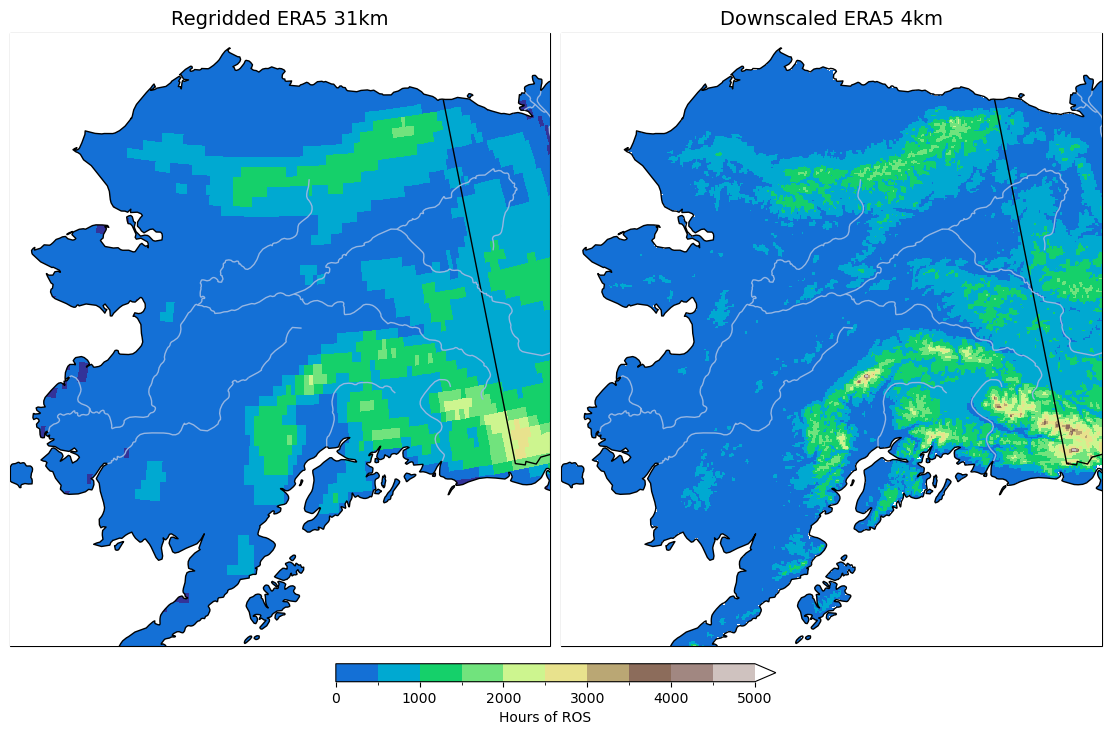

In [44]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154, central_latitude=50,
        standard_parallels=(55, 65))}

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(11,9), subplot_kw=AK_ALBERS_SUBPLOT_KW, constrained_layout=True)

cmap = 'terrain'
levels = tuple(range(0, 5500, 500))
norm = BoundaryNorm(levels, ncolors=plt.get_cmap(cmap).N, extend='both')
pc1 = axs[0].pcolormesh(elevation_31km['longitude'], elevation_31km['latitude'], 
                        elevation_31km.isel(time=0),
                        norm=norm, 
                        cmap=cmap,
                        shading='auto', transform=ccrs.PlateCarree())

axs[1].set_title("Downscaled ERA5 4km", fontsize=14)

pc2 = axs[1].pcolormesh(ROS_Tally_seasonal_era5_4km['XLONG'], ROS_Tally_seasonal_era5_4km['XLAT'], 
                        geo['HGT_M'].isel(Time=0).where(oceanmask != 17), 
                        cmap=cmap, 
                        norm=norm,  
                        shading='auto', transform=ccrs.PlateCarree())

axs[0].set_title("Regridded ERA5 31km", fontsize=14)

for ax in axs:
    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.add_feature(
    cfeature.OCEAN,
    facecolor='white',
    zorder=7)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    ax.set_aspect('equal')
#fig.suptitle("Terrain",fontsize=16, y=0.90)

cbar_ax = fig.add_axes([0.3, 0.12, 0.4, 0.02])
cbar = fig.colorbar(pc1, cax=cbar_ax, orientation='horizontal', extend='max', label='Hours of ROS')
cbar.ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
fig.patch.set_alpha(0.0)
plt.show()

In [25]:
ERA5_31km_REGRIDDED_ERA5_4km=xr.open_dataset('/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ERA5_31kmto4km_nearest_regridded.nc', engine='netcdf4')
ERA5_31km_REGRIDDED_ERA5_4km.transpose("south_north", "west_east",...)
ERA5_31km_REGRIDDED_ERA5_4km = ERA5_31km_REGRIDDED_ERA5_4km.where(oceanmask != 17)

ROS_Tally_nearest_regridded_ERA5_31km=np.sum(ERA5_31km_REGRIDDED_ERA5_4km['ros_tally'],axis=(1))
ROS_Tally_seasonal_nearest_regridded_ERA5_31km=np.mean(ROS_Tally_nearest_regridded_ERA5_31km ,axis=(0))
ROS_Tally_seasonal_nearest_regridded_ERA5_31km=ROS_Tally_seasonal_nearest_regridded_ERA5_31km.fillna(0)

ROS_RAIN_SUM_nearest_regridded_ERA5_31km=np.sum(ERA5_31km_REGRIDDED_ERA5_4km['rain_ros_sum'],axis=(1))
ROS_RAIN_SUM_nearest_regridded_ERA5_31km=np.mean(ROS_RAIN_SUM_nearest_regridded_ERA5_31km ,axis=(0))
ROS_RAIN_SUM_nearest_regridded_ERA5_31km=ROS_RAIN_SUM_nearest_regridded_ERA5_31km.fillna(0)


In [7]:
Difference_ROS_seasonal=ROS_Tally_seasonal_era5_4km-ROS_Tally_seasonal_nearest_regridded_ERA5_31km

In [7]:
#ros_colorbar = LinearSegmentedColormap.from_list('ros', ["saddlebrown", 'white', "darkblue"])
ros_colorbar = LinearSegmentedColormap.from_list('ros', ['darkred', 'orange', 'white', 'deepskyblue', 'midnightblue'])
#ros_colorbar = LinearSegmentedColormap.from_list('ros', ['#B86B4B', '#F1E5C0', '#5C6F8E'])
#ros_colorbar = LinearSegmentedColormap.from_list('ros', ['#B86B4B', 'white', '#5C6F8E'])

#ros_colorbar = LinearSegmentedColormap.from_list('ros', ['#B86B4B', 'white', '#4682B4'])
#ros_colorbar = LinearSegmentedColormap.from_list('ros', ['#B86B4B', '#D47F4D', 'white', '#6C8DA5', '#4682B4'])
#ros_colorbar = LinearSegmentedColormap.from_list('ros', ['#B86B4B', '#D47F4D', 'white', '#F0A500', '#1D4E89'])
ros_colorbar = LinearSegmentedColormap.from_list('ros', [
    '#4B2D1A',  
    '#6B3F1E',  
    '#A0522D',  
    '#D2B48C',  
    'white',     
    '#A1C6E8',  
    '#4682B4',  
    '#1E3A5F',  
    '#0A1F38' ])


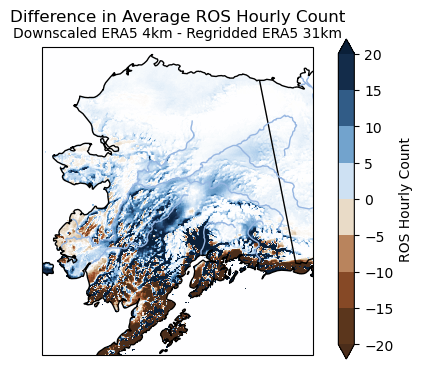

In [8]:
AK_ALBERS_SUBPLOT_KW = {'projection': ccrs.AlbersEqualArea(central_longitude=-154, central_latitude=50,standard_parallels=(55, 65))}
fig, ax = plt.subplots(subplot_kw=AK_ALBERS_SUBPLOT_KW, figsize=(10, 4))
fig.patch.set_alpha(0)
ax.set_facecolor('none')
levels=np.arange(-20,25,5)
cf = ax.pcolormesh(era54kmlon, era54kmlat, Difference_ROS_seasonal,vmin=-20, vmax=20,cmap=ros_colorbar,shading='auto',transform=ccrs.PlateCarree())

cbar = fig.colorbar(cf, ax=ax, boundaries=levels,label='ROS Hourly Count',extend='both',ticks=levels)
cbar.ax.set_position([0.77, 0.1, 0.02, 0.8])
ax.add_feature(cfeature.BORDERS, zorder=9)
ax.add_feature(cfeature.COASTLINE, zorder=9)
ax.add_feature(cfeature.RIVERS, zorder=9)
#ax.text(Fairbanks_lon, Fairbanks_lat + 0.05, 'Fairbanks', transform=ccrs.PlateCarree(),
#        ha='center', va='bottom', fontsize=8, zorder=6, fontweight='bold', color='black')

ax.set_title("Difference in Average ROS Hourly Count\n",fontsize=12)
ax.text(0.5, 1.03, "Downscaled ERA5 4km - Regridded ERA5 31km", transform=ax.transAxes, fontsize=10, ha='center')
ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
ax.set_aspect('equal') 
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

KeyboardInterrupt: 

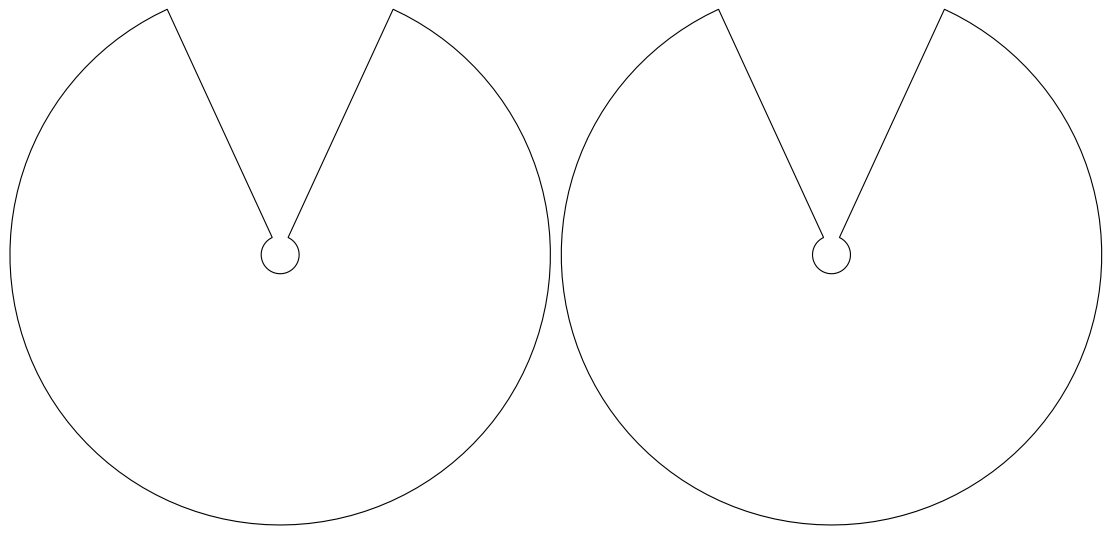

In [23]:

AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154, central_latitude=50,
        standard_parallels=(55, 65))}

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(11,9), subplot_kw=AK_ALBERS_SUBPLOT_KW, constrained_layout=True)

cmap = 'Blues'
levels = [1, 2, 5, 10, 20, 50,100]
norm = BoundaryNorm(levels, ncolors=plt.get_cmap(cmap).N, extend='both')
pc1 = axs[0].pcolormesh(ROS_Tally_seasonal_era5_4km['XLONG'], ROS_Tally_seasonal_era5_4km['XLAT'], 
                        ROS_Tally_seasonal_era5_4km, 
                        cmap=cmap, 
                        norm=norm, 
                        shading='auto', transform=ccrs.PlateCarree())

axs[0].set_title("Downscaled ERA5 4km", fontsize=14)

pc2 = axs[1].pcolormesh(ROS_Tally_seasonal_nearest_regridded_ERA5_31km['XLONG'], ROS_Tally_seasonal_nearest_regridded_ERA5_31km['XLAT'], 
                        ROS_Tally_seasonal_nearest_regridded_ERA5_31km, 
                        cmap=cmap, 
                        norm=norm,  
                        shading='auto', transform=ccrs.PlateCarree())

axs[1].set_title("Regridded ERA5 31km", fontsize=14)

for ax in axs:
    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    ax.set_aspect('equal')
fig.suptitle("Average Seasonal Hours of Rain on Snow",fontsize=16, y=0.90)

cbar_ax = fig.add_axes([0.3, 0.12, 0.4, 0.02])
cbar = fig.colorbar(pc1, cax=cbar_ax, orientation='horizontal', extend='max', label='Hours of ROS')
cbar.ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
fig.patch.set_alpha(0.0)
plt.show()

In [10]:

AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154, central_latitude=50,
        standard_parallels=(55, 65))
}

ros_levels  = [1, 2, 5, 10, 20, 50,100]
ros_cmap = plt.get_cmap('Blues')
ros_norm = BoundaryNorm(ros_levels, ncolors=ros_cmap.N, extend='both')

diff_levels = np.arange(-20,25,5)
diff_cmap = ros_colorbar
diff_norm = TwoSlopeNorm(vmin=diff_levels[0], vcenter=0, vmax=diff_levels[-1])

diff_data = ROS_Tally_seasonal_era5_4km - ROS_Tally_seasonal_nearest_regridded_ERA5_31km

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,7),
                        subplot_kw=AK_ALBERS_SUBPLOT_KW,
                        constrained_layout=True)

pc1 = axs[0].pcolormesh(
    ROS_Tally_seasonal_era5_4km['XLONG'], ROS_Tally_seasonal_era5_4km['XLAT'],
    ROS_Tally_seasonal_era5_4km,
    cmap=ros_cmap, norm=ros_norm,
    shading='auto', transform=ccrs.PlateCarree()
)
axs[0].set_title("Downscaled ERA5 4km", fontsize=14)

pc2 = axs[1].pcolormesh(
    ROS_Tally_seasonal_nearest_regridded_ERA5_31km['XLONG'], 
    ROS_Tally_seasonal_nearest_regridded_ERA5_31km['XLAT'],
    ROS_Tally_seasonal_nearest_regridded_ERA5_31km,
    cmap=ros_cmap, norm=ros_norm,
    shading='auto', transform=ccrs.PlateCarree()
)
axs[1].set_title("Regridded ERA5 31km", fontsize=14)

pc3 = axs[2].pcolormesh(
    ROS_Tally_seasonal_era5_4km['XLONG'], ROS_Tally_seasonal_era5_4km['XLAT'],
    diff_data,
    cmap=diff_cmap, norm=diff_norm,
    shading='auto', transform=ccrs.PlateCarree()
)
axs[2].set_title("Difference (4km − 31km)", fontsize=14)

for ax in axs:
    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    ax.set_aspect('equal')

cbar_ax1 = fig.add_axes([0.15, -0.05, 0.3, 0.04])
cbar1 = fig.colorbar(pc1, cax=cbar_ax1, orientation='horizontal',
                     ticks=ros_levels, extend='max', label='Hours of ROS')
cbar1.ax.tick_params(labelsize=13)
cbar1.set_label('Hours of ROS', fontsize=13)

cbar_ax2 = fig.add_axes([1.009, 0.1, 0.02, 0.8])
cbar2 = fig.colorbar(pc3, cax=cbar_ax2, orientation='vertical', boundaries=diff_levels,
                     ticks=diff_levels, extend='both', label=
                     'ROS Hour Difference (4km − 31km)')
cbar2.ax.tick_params(labelsize=13)
cbar2.set_label('ROS Hour Difference (4km − 31km)', fontsize=13)

fig.suptitle("Average Seasonal Hours of ROS ",fontweight='bold', fontsize=16, y=1.06)
fig.text(0.03, .95, 'A', fontsize=22, fontweight='bold', va='top', ha='left')
fig.text(0.37, .95, 'B', fontsize=22, fontweight='bold', va='top', ha='left')
fig.text(0.7, .95, 'C', fontsize=22, fontweight='bold', va='top', ha='left')
fig.patch.set_alpha(0.0)

plt.show()

NameError: name 'TwoSlopeNorm' is not defined

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm, TwoSlopeNorm
import matplotlib.ticker as ticker

AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))
}

rain_levels = [1, 2, 5, 10, 20, 50, 100]
rain_cmap = 'BuGn'
rain_norm = BoundaryNorm(rain_levels, ncolors=plt.get_cmap(rain_cmap).N, extend='both')


Rain_difference = ROS_Rain_seasonal_sum_era5_4km - ROS_RAIN_SUM_nearest_regridded_ERA5_31km
diff_levels = np.arange(-20, 25, 5)
diff_cmap = 'BrBG'
diff_norm = TwoSlopeNorm(vmin=diff_levels[0], vcenter=0, vmax=diff_levels[-1])

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,7),
                        subplot_kw=AK_ALBERS_SUBPLOT_KW,
                        constrained_layout=True)

pc1 = axs[0].pcolormesh(
    ROS_Rain_seasonal_sum_era5_4km['XLONG'], ROS_Rain_seasonal_sum_era5_4km['XLAT'], 
    ROS_Rain_seasonal_sum_era5_4km,
    cmap=rain_cmap,
    norm=rain_norm,
    shading='auto', transform=ccrs.PlateCarree()
)
axs[0].set_title("Downscaled ERA5 4km", fontsize=14)

pc2 = axs[1].pcolormesh(
    ROS_RAIN_SUM_nearest_regridded_ERA5_31km['XLONG'], ROS_RAIN_SUM_nearest_regridded_ERA5_31km['XLAT'], 
    ROS_RAIN_SUM_nearest_regridded_ERA5_31km,
    cmap=rain_cmap,
    norm=rain_norm,
    shading='auto', transform=ccrs.PlateCarree()
)
axs[1].set_title("Regridded ERA5 31km", fontsize=14)


pc3 = axs[2].pcolormesh(
    ROS_Rain_seasonal_sum_era5_4km['XLONG'], ROS_Rain_seasonal_sum_era5_4km['XLAT'], 
    Rain_difference,
    cmap=diff_cmap,
    norm=diff_norm,
    shading='auto', transform=ccrs.PlateCarree()
)
axs[2].set_title("Difference (4km − 31km)", fontsize=14)


for ax in axs:
    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    ax.set_aspect('equal')


cbar_ax1 = fig.add_axes([0.15, -0.05, 0.3, 0.04])
cbar1 = fig.colorbar(pc1, cax=cbar_ax1, orientation='horizontal',
                     ticks=rain_levels, extend='max', label='Rain Sum (mm)')
cbar1.ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
cbar1.ax.tick_params(labelsize=13)
cbar1.set_label('Rain Sum (mm)', fontsize=13)


cbar_ax2 = fig.add_axes([1.009, 0.1, 0.02, 0.8])
cbar2 = fig.colorbar(pc3, cax=cbar_ax2, orientation='vertical', boundaries=diff_levels,
                     ticks=diff_levels, extend='both', label='Rain Difference (mm)')
cbar2.ax.tick_params(labelsize=13)
cbar2.set_label('Rain Difference (4km − 31km)', fontsize=13)

fig.suptitle("Average Seasonal ROS Rainfall",fontweight='bold', fontsize=16, y=1.05)
fig.text(0.03, .95, 'D', fontsize=22, fontweight='bold', va='top', ha='left')
fig.text(0.37, .95, 'E', fontsize=22, fontweight='bold', va='top', ha='left')
fig.text(0.7, .95, 'F', fontsize=22, fontweight='bold', va='top', ha='left')

fig.patch.set_alpha(0.0)

plt.show()

NameError: name 'ROS_RAIN_SUM_nearest_regridded_ERA5_31km' is not defined

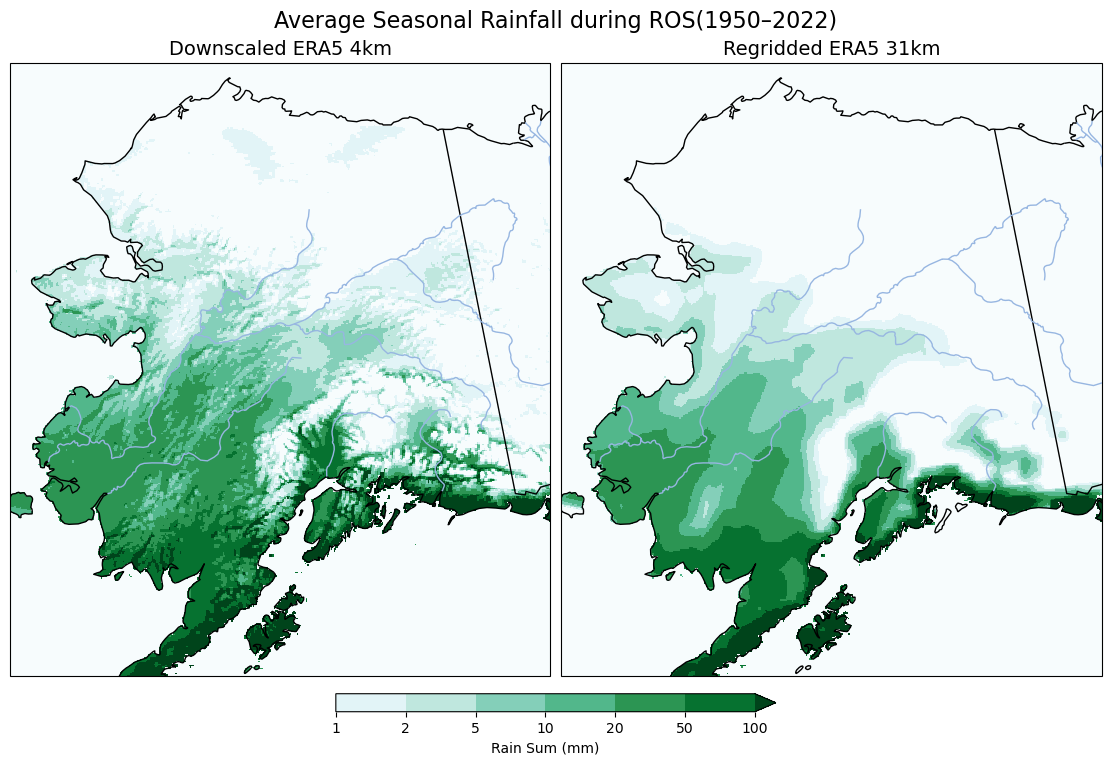

In [27]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154, central_latitude=50,
        standard_parallels=(55, 65))}

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(11,9), subplot_kw=AK_ALBERS_SUBPLOT_KW, constrained_layout=True)

cmap = 'BuGn'

levels = [1, 2, 5, 10, 20, 50,100]
#norm = BoundaryNorm(levels, ncolors=plt.get_cmap(cmap).N)
norm = BoundaryNorm(levels, ncolors=plt.get_cmap(cmap).N, extend='both')

pc1 = axs[0].pcolormesh(ROS_Rain_seasonal_sum_era5_4km['XLONG'], ROS_Rain_seasonal_sum_era5_4km['XLAT'], 
                        ROS_Rain_seasonal_sum_era5_4km, 
                        cmap=cmap, 
                        norm=norm,
                        shading='auto', transform=ccrs.PlateCarree())

axs[0].set_title("Downscaled ERA5 4km", fontsize=14)

# Use pcolormesh for ERA5 31km data
pc2 = axs[1].pcolormesh(ROS_RAIN_SUM_nearest_regridded_ERA5_31km['XLONG'], ROS_RAIN_SUM_nearest_regridded_ERA5_31km['XLAT'], 
                        ROS_RAIN_SUM_nearest_regridded_ERA5_31km, 
                        cmap=cmap, 
                        norm=norm,
                        shading='auto', transform=ccrs.PlateCarree())
axs[1].set_title("Regridded ERA5 31km", fontsize=14)

for ax in axs:
    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    ax.set_aspect('equal')

cbar_ax = fig.add_axes([0.3, 0.12, 0.4, 0.02])
cbar = fig.colorbar(pc1, cax=cbar_ax, orientation='horizontal', extend='max', label='Rain Sum (mm)')
cbar.ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

#fig.colorbar(pc1,extend='max', cax=cbar_ax,boundaries=levels,orientation='horizontal', label='Rain Sum (mm)', ticks=levels)
fig.suptitle("Average Seasonal Rainfall during ROS(1950–2022)",fontsize=16, y=0.90)
fig.patch.set_alpha(0.0)
plt.show()

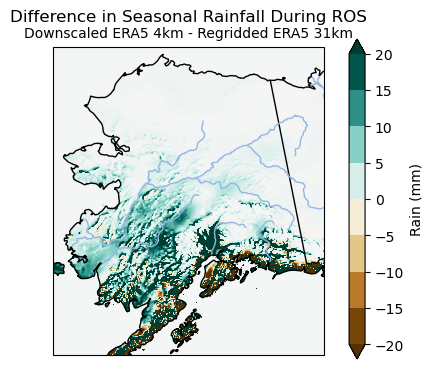

In [31]:
Rain_difference=(ROS_Rain_seasonal_sum_era5_4km-ROS_RAIN_SUM_nearest_regridded_ERA5_31km)

AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}

fig, ax = plt.subplots(subplot_kw=AK_ALBERS_SUBPLOT_KW, figsize=(10, 4))

levels=np.arange(-20, 25, 5)
fig.patch.set_alpha(0)
ax.set_facecolor('none')

pcm = ax.pcolormesh(
    lon, lat, Rain_difference,
    cmap='BrBG',
    vmin=-20, vmax=20,
    shading='auto',
    transform=ccrs.PlateCarree()
)

cbar = fig.colorbar(pcm, ax=ax,boundaries=levels, label='Rain (mm)',extend='both')
cbar.set_ticks(levels)
cbar.ax.set_position([0.77, 0.1, 0.02, 0.8])

ax.add_feature(cfeature.BORDERS, zorder=9)
ax.add_feature(cfeature.COASTLINE, zorder=9)
ax.add_feature(cfeature.RIVERS, zorder=9)

ax.set_title("Difference in Seasonal Rainfall During ROS\n",fontsize=12)
ax.text(0.5, 1.03, "Downscaled ERA5 4km - Regridded ERA5 31km", transform=ax.transAxes, fontsize=10, ha='center')

ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
ax.set_aspect('equal')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

In [28]:
Rain_difference=(ROS_RAIN_SUM_nearest_regridded_ERA5_4km-ROS_rain_sum_era5_31km)

AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}

fig, ax = plt.subplots(subplot_kw=AK_ALBERS_SUBPLOT_KW, figsize=(10, 4))

fig.patch.set_alpha(0)
ax.set_facecolor('none')

pcm = ax.pcolormesh(
    lon, lat, Rain_difference,
    cmap='coolwarm',
    vmin=-10, vmax=10,
    shading='auto',
    transform=ccrs.PlateCarree())

cbar = fig.colorbar(pcm, ax=ax, label='Rain (mm)')
cbar.set_ticks(np.arange(-10, 11, 1))
cbar.ax.set_position([0.77, 0.1, 0.02, 0.8])

ax.add_feature(cfeature.BORDERS, zorder=9)
ax.add_feature(cfeature.COASTLINE, zorder=9)
ax.add_feature(cfeature.RIVERS, zorder=9)

ax.set_title( "Difference in Seasonal Rainfall During ROS\n"
    "Regridded ERA5 4km - ERA5 31km \n"
    "for Winter 1950–2022")

ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
ax.set_aspect('equal')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

NameError: name 'ROS_RAIN_SUM_nearest_regridded_ERA5_4km' is not defined

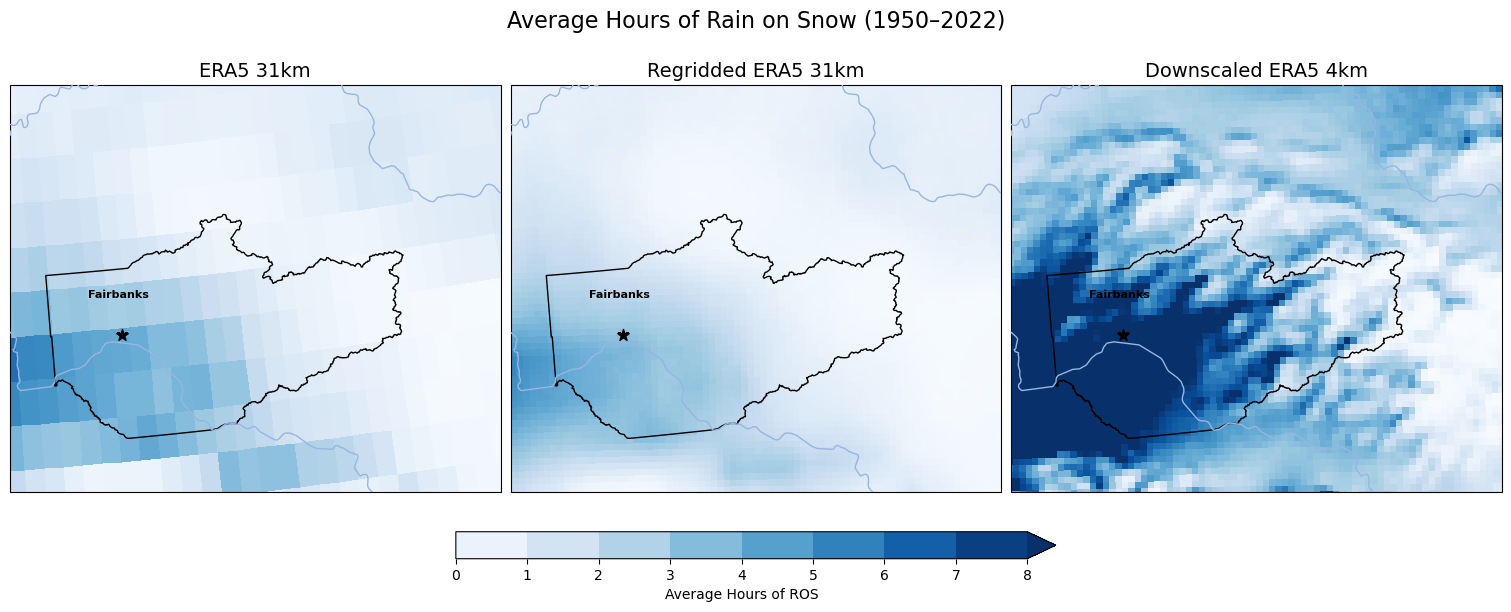

In [ ]:
path='/center1/DYNDOWN/phutton5/ROS/Raw_ERA5/Raw_ERA5_netcdf'
pattern=f'Raw_ERA5_ROS_Monthly*.nc'
file_list = sorted(glob.glob(os.path.join(path, pattern)))
ERA5_raw = xr.open_mfdataset(file_list, combine='by_coords',engine='netcdf4')
#data = data.fillna(0)


AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154, central_latitude=50,
        standard_parallels=(55, 65))}

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,9), subplot_kw=AK_ALBERS_SUBPLOT_KW, constrained_layout=True)

cmap = 'Blues'
levels=np.arange(0,9,1)

pc1 = axs[0].pcolormesh(ERA5_raw['longitude'], ERA5_raw['latitude'], 
                        np.mean(ERA5_raw['ros_tally'].sum(dim='month'),axis=0), 
                        cmap=cmap, 
                        vmin=levels[0], vmax=levels[-1], 
                        shading='auto', transform=ccrs.PlateCarree())

axs[0].set_title("ERA5 31km", fontsize=14)

pc2 = axs[1].pcolormesh(ROS_Tally_seasonal_nearest_regridded_ERA5_31km['XLONG'], ROS_Tally_seasonal_nearest_regridded_ERA5_31km['XLAT'], 
                        ROS_Tally_seasonal_nearest_regridded_ERA5_31km, 
                        cmap=cmap, 
                        vmin=levels[0], vmax=levels[-1], 
                        shading='auto', transform=ccrs.PlateCarree())

axs[1].set_title("Regridded ERA5 31km", fontsize=14)

pc1 = axs[2].pcolormesh(ROS_Tally_era5_4km['XLONG'], ROS_Tally_era5_4km['XLAT'], 
                        ROS_Tally_seasonal_era5_4km, 
                        cmap=cmap, 
                        vmin=levels[0], vmax=levels[-1], 
                        shading='auto', transform=ccrs.PlateCarree())

axs[2].set_title("Downscaled ERA5 4km", fontsize=14)

for ax in axs:
    FNSB_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, zorder=2, transform=ccrs.PlateCarree())
    ax.scatter(Fairbanks_lon, Fairbanks_lat, marker='*', color='k', s=75, zorder=9, transform=ccrs.PlateCarree())
    ax.text(Fairbanks_lon, Fairbanks_lat + 0.2, 'Fairbanks', ha='center', va='bottom', fontsize=8,
            fontweight='bold', color='black', zorder=6, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-149, -143, 64, 66], crs=ccrs.PlateCarree())
    ax.set_aspect('equal')
fig.suptitle("Average Hours of Rain on Snow (1950–2022)",fontsize=16, y=0.81)
cbar_ax = fig.add_axes([0.3, 0.20, 0.4, 0.03])
fig.colorbar(pc1, cax=cbar_ax,boundaries=levels, orientation='horizontal', label='Average Hours of ROS', ticks=levels,extend='max')

fig.patch.set_alpha(0.0)
plt.show()

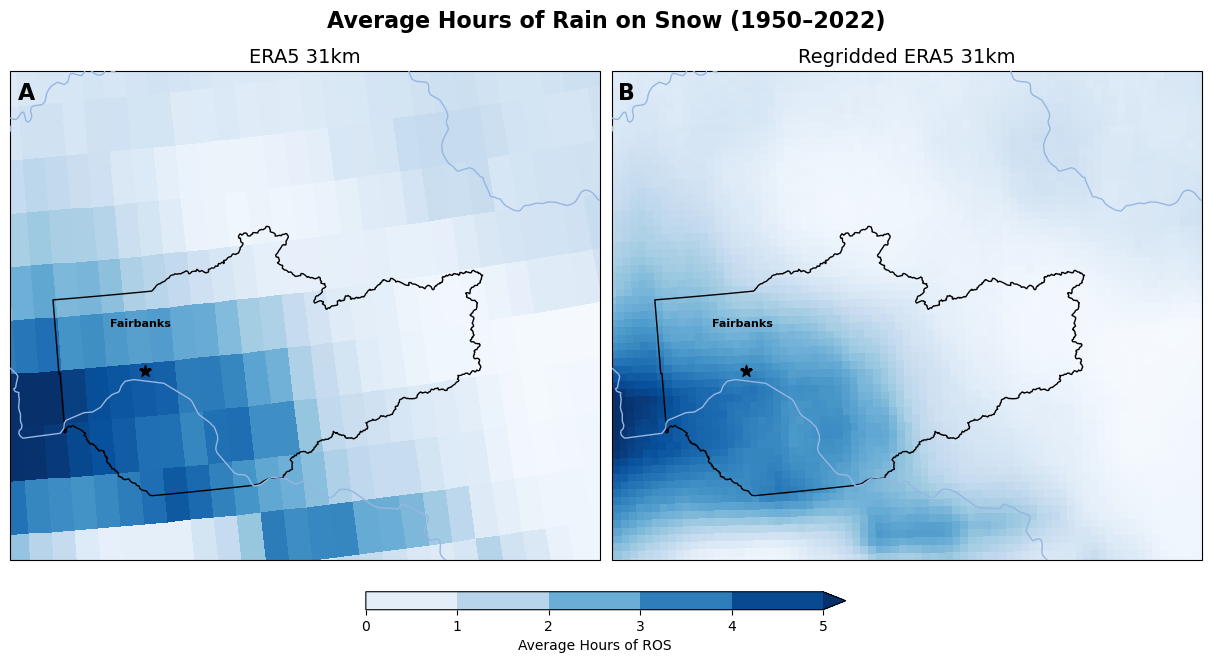

In [64]:
path='/center1/DYNDOWN/phutton5/ROS/Raw_ERA5/Raw_ERA5_netcdf'
pattern=f'Raw_ERA5_ROS_Monthly*.nc'
file_list = sorted(glob.glob(os.path.join(path, pattern)))
ERA5_raw = xr.open_mfdataset(file_list, combine='by_coords',engine='netcdf4')
#data = data.fillna(0)


AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154, central_latitude=50,
        standard_parallels=(55, 65))}

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,6), subplot_kw=AK_ALBERS_SUBPLOT_KW, constrained_layout=True)

cmap = 'Blues'
levels=np.arange(0,6,1)

pc1 = axs[0].pcolormesh(ERA5_raw['longitude'], ERA5_raw['latitude'], 
                        np.mean(ERA5_raw['ros_tally'].sum(dim='month'),axis=0), 
                        cmap=cmap, 
                        vmin=levels[0], vmax=levels[-1], 
                        shading='auto', transform=ccrs.PlateCarree())

axs[0].set_title("ERA5 31km", fontsize=14)

pc2 = axs[1].pcolormesh(ROS_Tally_seasonal_nearest_regridded_ERA5_31km['XLONG'], ROS_Tally_seasonal_nearest_regridded_ERA5_31km['XLAT'], 
                        ROS_Tally_seasonal_nearest_regridded_ERA5_31km, 
                        cmap=cmap, 
                        vmin=levels[0], vmax=levels[-1], 
                        shading='auto', transform=ccrs.PlateCarree())

axs[1].set_title("Regridded ERA5 31km", fontsize=14)

for ax in axs:
    FNSB_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, zorder=2, transform=ccrs.PlateCarree())
    ax.scatter(Fairbanks_lon, Fairbanks_lat, marker='*', color='k', s=75, zorder=9, transform=ccrs.PlateCarree())
    ax.text(Fairbanks_lon, Fairbanks_lat + 0.2, 'Fairbanks', ha='center', va='bottom', fontsize=8,
            fontweight='bold', color='black', zorder=6, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-149, -143, 64, 66], crs=ccrs.PlateCarree())
    ax.set_aspect('equal')
fig.suptitle("Average Hours of Rain on Snow (1950–2022)",fontsize=16, y=1.01,fontweight='bold')
cbar_ax = fig.add_axes([0.3, 0.01, 0.4, 0.03])
fig.colorbar(pc1, cax=cbar_ax,boundaries=levels, orientation='horizontal', label='Average Hours of ROS', ticks=levels,extend='max')
cbar.ax.tick_params(labelsize=13)
cbar.set_label('Average Hours of ROS', fontsize=13)


fig.text(0.01, 0.89, 'A', fontsize=16, fontweight='bold', va='top', ha='left')
fig.text(0.51, 0.89, 'B', fontsize=16, fontweight='bold', va='top', ha='left')
fig.patch.set_alpha(0.0)
plt.show()

FAIRBANKS
-

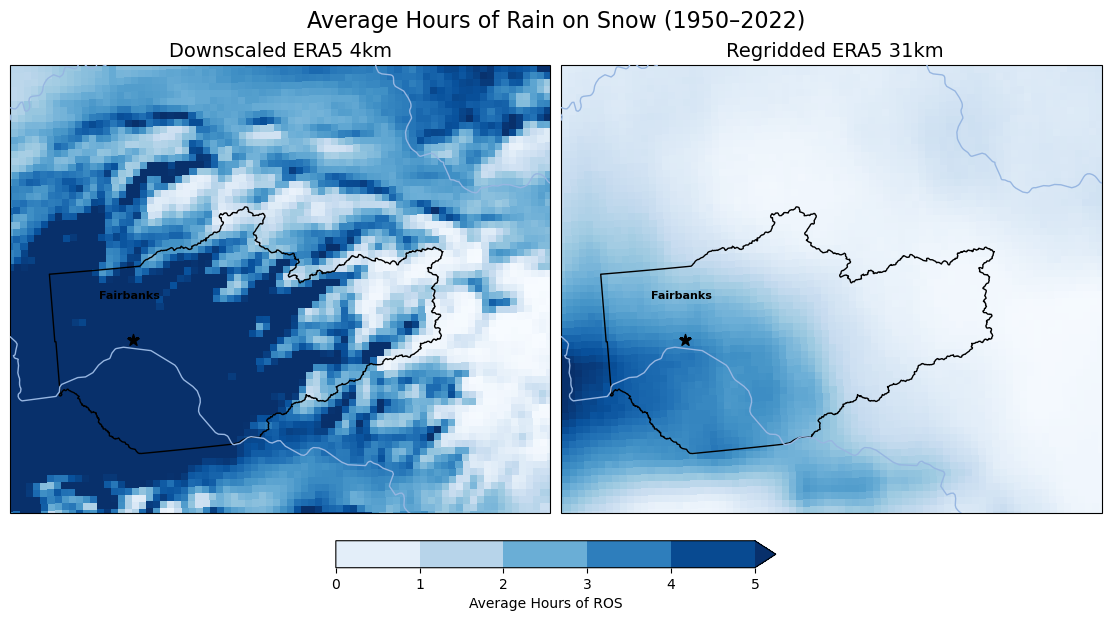

In [ ]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154, central_latitude=50,
        standard_parallels=(55, 65))}

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(11,9), subplot_kw=AK_ALBERS_SUBPLOT_KW, constrained_layout=True)

# Create color map and levels
cmap = 'Blues'
levels=np.arange(0,6,1)

# Use pcolormesh instead of contourf
pc1 = axs[0].pcolormesh(ROS_Tally_era5_4km['XLONG'], ROS_Tally_era5_4km['XLAT'], 
                        ROS_Tally_seasonal_era5_4km, 
                        cmap=cmap, 
                        vmin=levels[0], vmax=levels[-1], 
                        shading='auto', transform=ccrs.PlateCarree())

axs[0].set_title("Downscaled ERA5 4km", fontsize=14)

# Use pcolormesh for ERA5 31km data
pc2 = axs[1].pcolormesh(ROS_Tally_seasonal_nearest_regridded_ERA5_31km['XLONG'], ROS_Tally_seasonal_nearest_regridded_ERA5_31km['XLAT'], 
                        ROS_Tally_seasonal_nearest_regridded_ERA5_31km, 
                        cmap=cmap, 
                        vmin=levels[0], vmax=levels[-1], 
                        shading='auto', transform=ccrs.PlateCarree())

axs[1].set_title(" Regridded ERA5 31km", fontsize=14)

for ax in axs:
    FNSB_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, zorder=2, transform=ccrs.PlateCarree())
    ax.scatter(Fairbanks_lon, Fairbanks_lat, marker='*', color='k', s=75, zorder=9, transform=ccrs.PlateCarree())
    ax.text(Fairbanks_lon, Fairbanks_lat + 0.2, 'Fairbanks', ha='center', va='bottom', fontsize=8,
            fontweight='bold', color='black', zorder=6, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-149, -143, 64, 66], crs=ccrs.PlateCarree())
    ax.set_aspect('equal')
fig.suptitle("Average Hours of Rain on Snow (1950–2022)",fontsize=16, y=0.81)
cbar_ax = fig.add_axes([0.3, 0.19, 0.4, 0.03])
fig.colorbar(pc1, cax=cbar_ax, orientation='horizontal',boundaries=levels, label='Average Hours of ROS', ticks=levels,extend='max')

fig.patch.set_alpha(0.0)
plt.show()

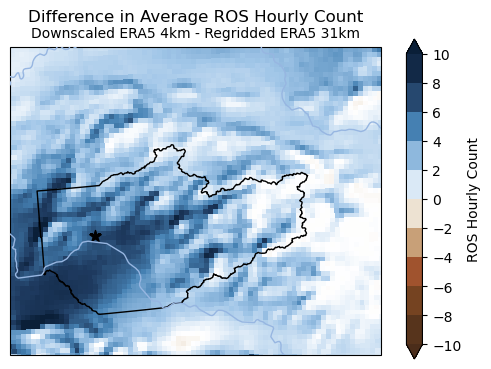

In [ ]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}

fig, ax = plt.subplots(subplot_kw=AK_ALBERS_SUBPLOT_KW, figsize=(10, 4))

fig.patch.set_alpha(0)
ax.set_facecolor('none')

levels=np.arange(-10, 12, 2)

pcm = ax.pcolormesh(
    lon, lat, Difference_ROS_seasonal,
    cmap=ros_colorbar,
    vmin=-10, vmax=10,
    shading='auto',
    transform=ccrs.PlateCarree()
)

cbar = fig.colorbar(pcm, ax=ax, boundaries=levels, label='ROS Hourly Count',extend='both')
cbar.set_ticks(levels)
cbar.ax.set_position([0.77, 0.1, 0.02, 0.8])

FNSB_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, zorder=2, transform=ccrs.PlateCarree())
ax.scatter(
    Fairbanks_lon, Fairbanks_lat,
    marker='*', color='k',
    zorder=5, s=75,
    label='Fairbanks',
    transform=ccrs.PlateCarree())

# Map features
ax.add_feature(cfeature.BORDERS, zorder=9)
ax.add_feature(cfeature.COASTLINE, zorder=9)
ax.add_feature(cfeature.RIVERS, zorder=9)
ax.text(0.5, 1.03, "Downscaled ERA5 4km - Regridded ERA5 31km", transform=ax.transAxes, fontsize=10, ha='center')
ax.set_title("Difference in Average ROS Hourly Count\n")

ax.set_extent([-149, -143, 64, 66], crs=ccrs.PlateCarree())
ax.set_aspect('equal')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

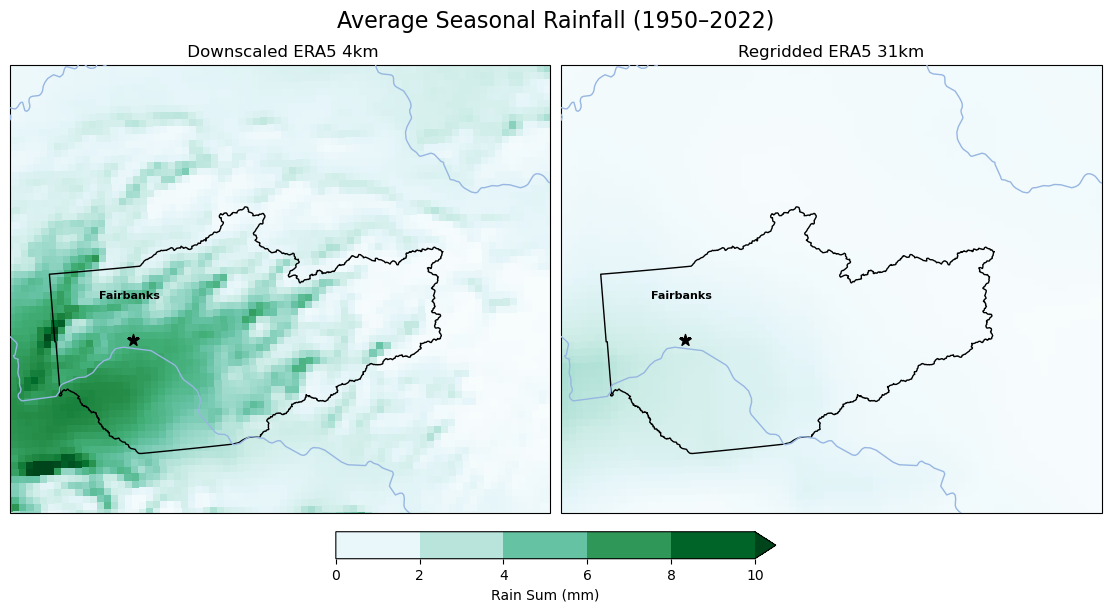

In [8]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154, central_latitude=50,
        standard_parallels=(55, 65))}

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(11,9), subplot_kw=AK_ALBERS_SUBPLOT_KW, constrained_layout=True)

# Create color map and levels
cmap = 'BuGn'
levels=np.arange(0, 12, 2)
# Use pcolormesh instead of contourf
pc1 = axs[0].pcolormesh(ROS_Rain_seasonal_sum_era5_4km['XLONG'], ROS_Rain_seasonal_sum_era5_4km['XLAT'], 
                        ROS_Rain_seasonal_sum_era5_4km, 
                        cmap=cmap, 
                        vmin=levels[0], vmax=levels[-1], 
                        shading='auto', transform=ccrs.PlateCarree())

axs[0].set_title(" Downscaled ERA5 4km", fontsize=12)

# Use pcolormesh for ERA5 31km data
pc2 = axs[1].pcolormesh(ROS_RAIN_SUM_nearest_regridded_ERA5_31km['XLONG'], ROS_RAIN_SUM_nearest_regridded_ERA5_31km['XLAT'], 
                        ROS_RAIN_SUM_nearest_regridded_ERA5_31km, 
                        cmap=cmap, 
                        vmin=levels[0], vmax=levels[-1], 
                        shading='auto', transform=ccrs.PlateCarree())
#average seasonal sum of rainfall during ROS events 
#Average Seasonal Rainfall from Winter 1950-2022 
axs[1].set_title("Regridded ERA5 31km", fontsize=12)

for ax in axs:
    FNSB_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, zorder=2, transform=ccrs.PlateCarree())
    ax.scatter(Fairbanks_lon, Fairbanks_lat, marker='*', color='k', s=75, zorder=9, transform=ccrs.PlateCarree())
    ax.text(Fairbanks_lon, Fairbanks_lat + 0.2, 'Fairbanks', ha='center', va='bottom', fontsize=8,
            fontweight='bold', color='black', zorder=6, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-149, -143, 64, 66], crs=ccrs.PlateCarree())
    ax.set_aspect('equal')

#fig.suptitle("Average Hours of Rain on Snow (1950–2022)",fontsize=16, y=0.81)
fig.suptitle("Average Seasonal Rainfall (1950–2022)",fontsize=16, y=0.81)
cbar_ax = fig.add_axes([0.3, 0.20, 0.4, 0.03])
fig.colorbar(pc1,extend='max', cax=cbar_ax,boundaries=levels, orientation='horizontal', label='Rain Sum (mm)', ticks=levels)

fig.patch.set_alpha(0.0)
plt.show()

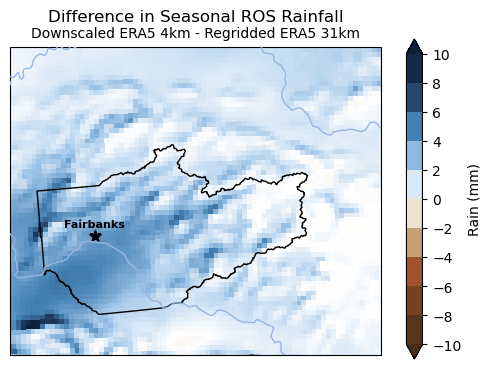

In [28]:
AK_ALBERS_SUBPLOT_KW = {'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))}

fig, ax = plt.subplots(subplot_kw=AK_ALBERS_SUBPLOT_KW, figsize=(10, 4))
fig.patch.set_alpha(0)
levels=(np.arange(-10, 12, 2))
ax.set_facecolor('none')
pcm = ax.pcolormesh(
    lon, lat, Rain_difference,
    cmap=ros_colorbar,
    vmin=-10, vmax=10,
    shading='auto',
    transform=ccrs.PlateCarree())

cbar = fig.colorbar(pcm, ax=ax,boundaries=levels, label='Rain (mm)',extend='both')
cbar.set_ticks(levels)
cbar.ax.set_position([0.77, 0.1, 0.02, 0.8])

FNSB_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, zorder=2, transform=ccrs.PlateCarree())
ax.scatter(
    Fairbanks_lon, Fairbanks_lat,
    marker='*', color='k',
    zorder=5, s=75,
    label='Fairbanks',
    transform=ccrs.PlateCarree())

ax.add_feature(cfeature.BORDERS, zorder=9)
ax.add_feature(cfeature.COASTLINE, zorder=9)
ax.add_feature(cfeature.RIVERS, zorder=9)

ax.text(
    Fairbanks_lon, Fairbanks_lat + 0.05, 'Fairbanks',
    transform=ccrs.PlateCarree(),
    ha='center', va='bottom',
    fontsize=8, zorder=6,
    fontweight='bold', color='black')

ax.text(0.5, 1.03, "Downscaled ERA5 4km - Regridded ERA5 31km", transform=ax.transAxes, fontsize=10, ha='center')
ax.set_title("Difference in Seasonal ROS Rainfall\n")
ax.set_extent([-149, -143, 64, 66], crs=ccrs.PlateCarree())
ax.set_aspect('equal')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

BETHEL
-

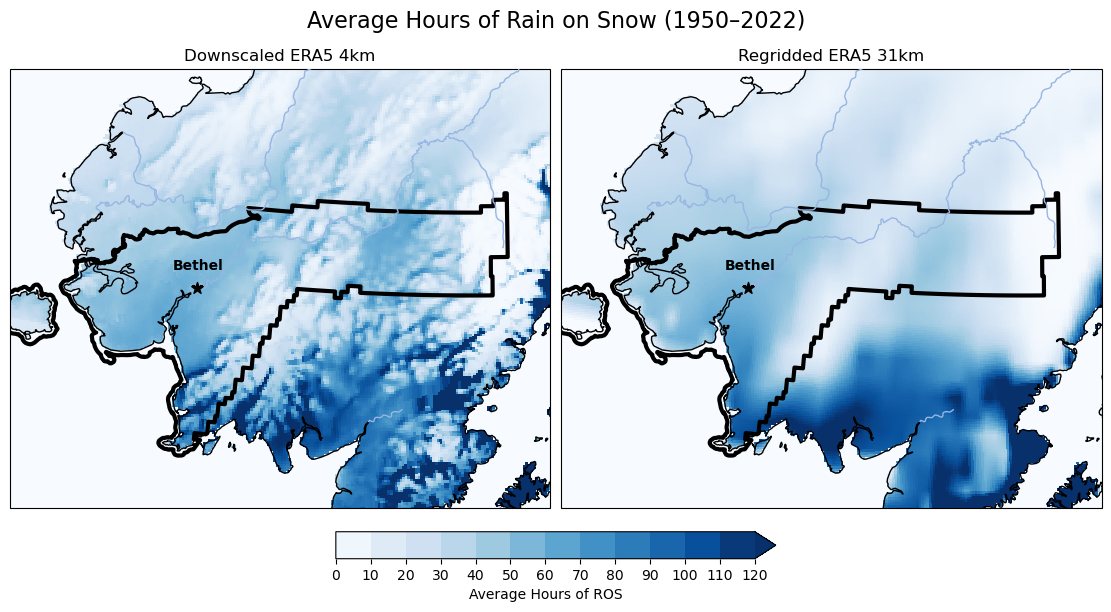

In [ ]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154, central_latitude=50,
        standard_parallels=(55, 65))}

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(11,9), subplot_kw=AK_ALBERS_SUBPLOT_KW, constrained_layout=True)

# Create color map and levels
cmap = 'Blues'

levels=np.arange(0,130,10)

# Use pcolormesh instead of contourf
pc1 = axs[0].pcolormesh(ROS_Tally_era5_4km['XLONG'], ROS_Tally_era5_4km['XLAT'], 
                        ROS_Tally_seasonal_era5_4km, 
                        cmap=cmap, 
                        vmin=levels[0], vmax=levels[-1], 
                        shading='auto', transform=ccrs.PlateCarree())

axs[0].set_title("Downscaled ERA5 4km", fontsize=12)

# Use pcolormesh for ERA5 31km data
pc2 = axs[1].pcolormesh(ROS_Tally_seasonal_nearest_regridded_ERA5_31km['XLONG'], ROS_Tally_seasonal_nearest_regridded_ERA5_31km['XLAT'], 
                        ROS_Tally_seasonal_nearest_regridded_ERA5_31km, 
                        cmap=cmap, 
                        vmin=levels[0], vmax=levels[-1], 
                        shading='auto', transform=ccrs.PlateCarree())

axs[1].set_title("Regridded ERA5 31km", fontsize=12)

for ax in axs:
    Bethel_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=3, zorder=2, transform=ccrs.PlateCarree())
    Bethel_lon = -161.7554
    Bethel_lat = 60.7913
    ax.scatter(Bethel_lon, Bethel_lat, marker='*', color='black', s=75, zorder=12, transform=ccrs.PlateCarree())
    ax.text(Bethel_lon, Bethel_lat + 0.2, 'Bethel', ha='center', va='bottom', fontsize=10,
       fontweight='bold', color='black', zorder=12, transform=ccrs.PlateCarree())


    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-166.0, -152.0, 58.0, 63.5], crs=ccrs.PlateCarree())
    ax.set_aspect('equal')

cbar_ax = fig.add_axes([0.3, 0.2, 0.4, 0.03])
fig.colorbar(pc1, cax=cbar_ax, boundaries=levels,orientation='horizontal', label='Average Hours of ROS', ticks=levels,extend='max')
fig.suptitle("Average Hours of Rain on Snow (1950–2022)",fontsize=16, y=0.81)

fig.patch.set_alpha(0.0)
plt.show()

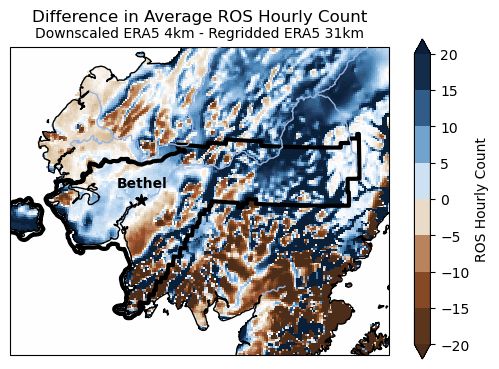

In [ ]:
AK_ALBERS_SUBPLOT_KW = {'projection': ccrs.AlbersEqualArea(
       central_longitude=-154,
       central_latitude=50,
       standard_parallels=(55, 65))}

levels=np.arange(-20, 25, 5)
fig, ax = plt.subplots(subplot_kw=AK_ALBERS_SUBPLOT_KW, figsize=(10, 4))
fig.patch.set_alpha(0)
ax.set_facecolor('none')
pcm = ax.pcolormesh(lon, lat, Difference_ROS_seasonal,
   cmap=ros_colorbar,
   vmin=-20, vmax=20,
   shading='auto',
   transform=ccrs.PlateCarree())

cbar = fig.colorbar(pcm, ax=ax, boundaries=levels,label='ROS Hourly Count',extend='both')
cbar.set_ticks(levels)
cbar.ax.set_position([0.77, 0.1, 0.02, 0.8])

Bethel_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=3, zorder=2, transform=ccrs.PlateCarree())
Bethel_lon = -161.7554
Bethel_lat = 60.7913
ax.scatter(Bethel_lon, Bethel_lat, marker='*', color='black', s=75, zorder=12, transform=ccrs.PlateCarree())
ax.text(Bethel_lon, Bethel_lat + 0.2, 'Bethel', ha='center', va='bottom', fontsize=10,
       fontweight='bold', color='black', zorder=12, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, zorder=9)
ax.add_feature(cfeature.COASTLINE, zorder=9)
ax.add_feature(cfeature.RIVERS, zorder=9)

ax.text(0.5, 1.03, "Downscaled ERA5 4km - Regridded ERA5 31km", transform=ax.transAxes, fontsize=10, ha='center')
ax.set_title("Difference in Average ROS Hourly Count\n")

ax.set_extent([-166.0, -152.0, 58.0, 63.5], crs=ccrs.PlateCarree())
ax.set_aspect('equal')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()


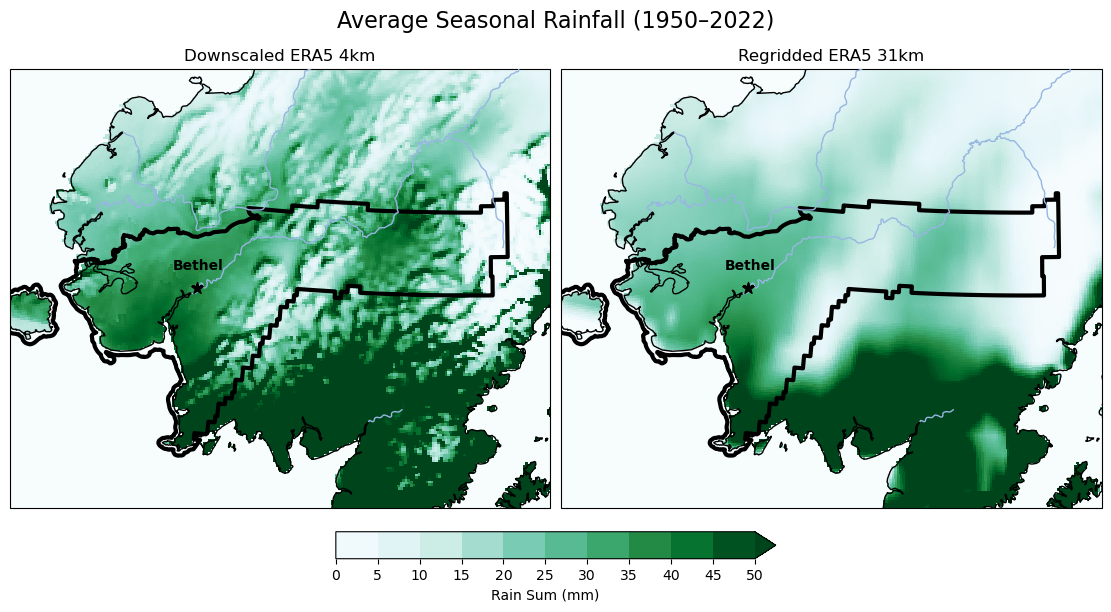

In [ ]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154, central_latitude=50,
        standard_parallels=(55, 65))}

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(11,9), subplot_kw=AK_ALBERS_SUBPLOT_KW, constrained_layout=True)

# Create color map and levels
cmap = 'BuGn'
levels=np.arange(0, 55, 5)

# Use pcolormesh instead of contourf
pc1 = axs[0].pcolormesh(ROS_Rain_seasonal_sum_era5_4km['XLONG'], ROS_Rain_seasonal_sum_era5_4km['XLAT'], 
                        ROS_Rain_seasonal_sum_era5_4km, 
                        cmap=cmap, 
                        vmin=levels[0], vmax=levels[-1], 
                        shading='auto', transform=ccrs.PlateCarree())

axs[0].set_title("Downscaled ERA5 4km", fontsize=12)

# Use pcolormesh for ERA5 31km data
pc2 = axs[1].pcolormesh(ROS_RAIN_SUM_nearest_regridded_ERA5_31km['XLONG'], ROS_RAIN_SUM_nearest_regridded_ERA5_31km['XLAT'], 
                        ROS_RAIN_SUM_nearest_regridded_ERA5_31km, 
                        cmap=cmap, 
                        vmin=levels[0], vmax=levels[-1], 
                        shading='auto', transform=ccrs.PlateCarree())

axs[1].set_title("Regridded ERA5 31km", fontsize=12)


fig.suptitle("Average Seasonal Rainfall (1950–2022)",fontsize=16, y=0.81)
for ax in axs:
    Bethel_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=3, zorder=2, transform=ccrs.PlateCarree())
    Bethel_lon = -161.7554
    Bethel_lat = 60.7913
    ax.scatter(Bethel_lon, Bethel_lat, marker='*', color='black', s=75, zorder=12, transform=ccrs.PlateCarree())
    ax.text(Bethel_lon, Bethel_lat + 0.2, 'Bethel', ha='center', va='bottom', fontsize=10,
       fontweight='bold', color='black', zorder=12, transform=ccrs.PlateCarree())   
    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-166.0, -152.0, 58.0, 63.5], crs=ccrs.PlateCarree())
    ax.set_aspect('equal')

cbar_ax = fig.add_axes([0.3, 0.2, 0.4, 0.03])
fig.colorbar(pc1,extend='max', boundaries=levels,cax=cbar_ax, orientation='horizontal', label='Rain Sum (mm)', ticks=levels)

fig.patch.set_alpha(0.0)
plt.show()

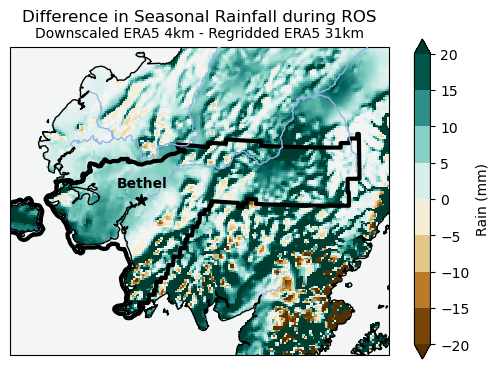

In [ ]:
AK_ALBERS_SUBPLOT_KW = {'projection': ccrs.AlbersEqualArea(
       central_longitude=-154,
       central_latitude=50,
       standard_parallels=(55, 65))}

fig, ax = plt.subplots(subplot_kw=AK_ALBERS_SUBPLOT_KW, figsize=(10, 4))
fig.patch.set_alpha(0)

levels=np.arange(-20, 25, 5)
               
ax.set_facecolor('none')
pcm = ax.pcolormesh(lon, lat,Rain_difference,
   cmap='BrBG',
   vmin=-20, vmax=20,
   shading='auto',
   transform=ccrs.PlateCarree())

cbar = fig.colorbar(pcm, boundaries=levels, ax=ax, label='Rain (mm)',extend='both')
cbar.set_ticks(levels)
cbar.ax.set_position([0.77, 0.1, 0.02, 0.8])

Bethel_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=3, zorder=2, transform=ccrs.PlateCarree())
Bethel_lon = -161.7554
Bethel_lat = 60.7913
ax.scatter(Bethel_lon, Bethel_lat, marker='*', color='black', s=75, zorder=12, transform=ccrs.PlateCarree())
ax.text(Bethel_lon, Bethel_lat + 0.2, 'Bethel', ha='center', va='bottom', fontsize=10,
       fontweight='bold', color='black', zorder=12, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, zorder=9)
ax.add_feature(cfeature.COASTLINE, zorder=9)
ax.add_feature(cfeature.RIVERS, zorder=9)

ax.set_title("Difference in Seasonal Rainfall during ROS\n")

ax.text(0.5, 1.03, "Downscaled ERA5 4km - Regridded ERA5 31km", transform=ax.transAxes, fontsize=10, ha='center')

ax.set_extent([-166.0, -152.0, 58.0, 63.5], crs=ccrs.PlateCarree())
ax.set_aspect('equal')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

Anchorage
-

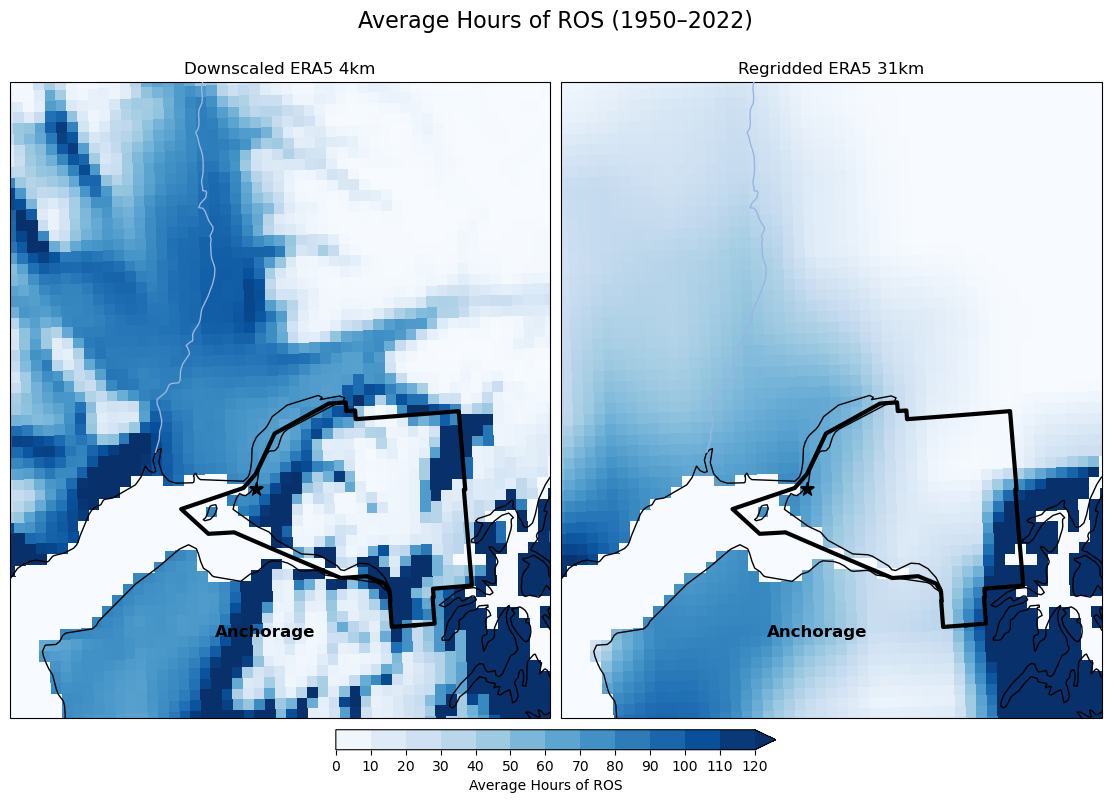

In [ ]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154, central_latitude=50,
        standard_parallels=(55, 65))}

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(11,10), subplot_kw=AK_ALBERS_SUBPLOT_KW, constrained_layout=True)

# Create color map and levels
cmap = 'Blues'
levels=np.arange(0,130,10)

# Use pcolormesh instead of contourf
pc1 = axs[0].pcolormesh(ROS_Tally_era5_4km['XLONG'], ROS_Tally_era5_4km['XLAT'], 
                        ROS_Tally_seasonal_era5_4km, 
                        cmap=cmap, 
                        vmin=levels[0], vmax=levels[-1], 
                        shading='auto', transform=ccrs.PlateCarree())

axs[0].set_title("Downscaled ERA5 4km", fontsize=12)

# Use pcolormesh for ERA5 31km data
pc2 = axs[1].pcolormesh(ROS_Tally_seasonal_nearest_regridded_ERA5_31km['XLONG'], ROS_Tally_seasonal_nearest_regridded_ERA5_31km['XLAT'], 
                        ROS_Tally_seasonal_nearest_regridded_ERA5_31km, 
                        cmap=cmap, 
                        vmin=levels[0], vmax=levels[-1], 
                        shading='auto', transform=ccrs.PlateCarree())

axs[1].set_title("Regridded ERA5 31km", fontsize=12)

for ax in axs:
    Mun_of_Anc_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=3, zorder=2, transform=ccrs.PlateCarree())
    Anchorage_lon = -149.9003
    Anchorage_lat = 61.2181
    ax.scatter(Anchorage_lon, Anchorage_lat, marker='*', color='black', s=100,zorder=9, transform=ccrs.PlateCarree())
    ax.text(Anchorage_lon, Anchorage_lat - 0.5, 'Anchorage', ha='center', va='bottom', fontsize=12,
       fontweight='bold', color='black', zorder=10, transform=ccrs.PlateCarree())

    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree()) 
    ax.set_aspect('equal')

cbar_ax = fig.add_axes([0.3, 0.15, 0.4, 0.02])
fig.colorbar(pc1, cax=cbar_ax, boundaries=levels, orientation='horizontal', label='Average Hours of ROS', ticks=levels,extend='max')

fig.suptitle("Average Hours of ROS (1950–2022)",fontsize=16, y=0.89)

fig.patch.set_alpha(0.0)
plt.show()

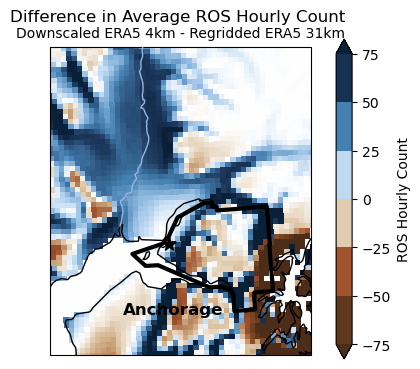

In [ ]:
AK_ALBERS_SUBPLOT_KW = {'projection': ccrs.AlbersEqualArea(
       central_longitude=-154,
       central_latitude=50,
       standard_parallels=(55, 65))}

fig, ax = plt.subplots(subplot_kw=AK_ALBERS_SUBPLOT_KW, figsize=(10, 4))
fig.patch.set_alpha(0)
ax.set_facecolor('none')

levels=np.arange(-75,100, 25)

pcm = ax.pcolormesh(lon, lat, Difference_ROS_seasonal,
   cmap=ros_colorbar,
   vmin=-75, vmax=75,
   shading='auto',
   transform=ccrs.PlateCarree())

cbar = fig.colorbar(pcm, ax=ax, boundaries=levels,label='ROS Hourly Count',extend='both')
cbar.set_ticks(levels)
cbar.ax.set_position([0.77, 0.1, 0.02, 0.8])

Mun_of_Anc_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=3, zorder=2, transform=ccrs.PlateCarree())
Anchorage_lon = -149.9003
Anchorage_lat = 61.2181
ax.scatter(Anchorage_lon, Anchorage_lat, marker='*', color='black', s=100,zorder=9, transform=ccrs.PlateCarree())
ax.text(Anchorage_lon, Anchorage_lat - 0.5, 'Anchorage', ha='center', va='bottom', fontsize=12,
       fontweight='bold', color='black', zorder=10, transform=ccrs.PlateCarree())

ax.add_feature(cfeature.BORDERS, zorder=9)
ax.add_feature(cfeature.COASTLINE, zorder=9)
ax.add_feature(cfeature.RIVERS, zorder=9)

ax.set_title("Difference in Average ROS Hourly Count \n")
ax.text(0.5, 1.03, "Downscaled ERA5 4km - Regridded ERA5 31km", transform=ax.transAxes, fontsize=10, ha='center')
#   "Regridded 4km ERA5 - ERA5 31km)
ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree()) 
ax.set_aspect('equal')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

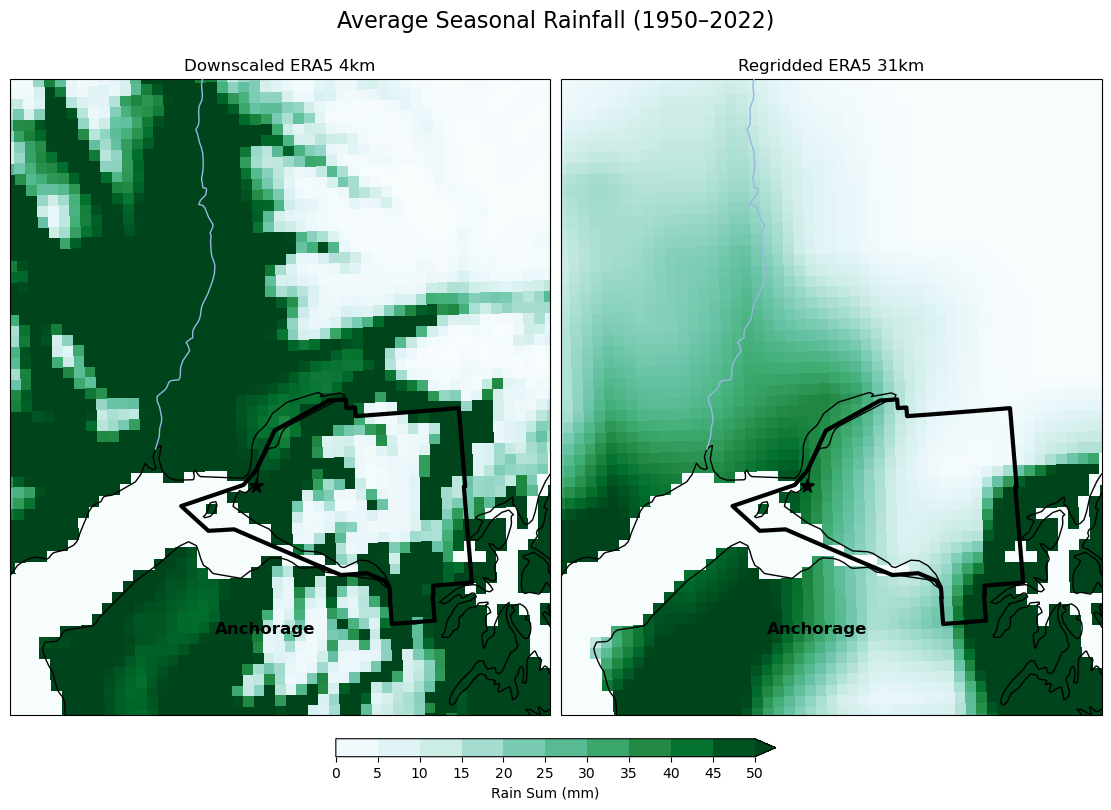

In [ ]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154, central_latitude=50,
        standard_parallels=(55, 65))}

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(11,9), subplot_kw=AK_ALBERS_SUBPLOT_KW, constrained_layout=True)

# Create color map and levels
cmap = 'BuGn'
levels=np.arange(0, 55, 5)

# Use pcolormesh instead of contourf
pc1 = axs[0].pcolormesh(ROS_Rain_seasonal_sum_era5_4km['XLONG'], ROS_Rain_seasonal_sum_era5_4km['XLAT'], 
                        ROS_Rain_seasonal_sum_era5_4km, 
                        cmap=cmap, 
                        vmin=levels[0], vmax=levels[-1], 
                        shading='auto', transform=ccrs.PlateCarree())

axs[0].set_title("Downscaled ERA5 4km", fontsize=12)

# Use pcolormesh for ERA5 31km data
pc2 = axs[1].pcolormesh(ROS_RAIN_SUM_nearest_regridded_ERA5_31km['XLONG'], ROS_RAIN_SUM_nearest_regridded_ERA5_31km['XLAT'], 
                        ROS_RAIN_SUM_nearest_regridded_ERA5_31km, 
                        cmap=cmap, 
                        vmin=levels[0], vmax=levels[-1], 
                        shading='auto', transform=ccrs.PlateCarree())
#average seasonal sum of rainfall during ROS events 
#Average Seasonal Rainfall from Winter 1950-2022 
axs[1].set_title("Regridded ERA5 31km", fontsize=12)

for ax in axs:
    Mun_of_Anc_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=3, zorder=2, transform=ccrs.PlateCarree())
    Anchorage_lon = -149.9003
    Anchorage_lat = 61.2181
    ax.scatter(Anchorage_lon, Anchorage_lat, marker='*', color='black', s=100,zorder=9, transform=ccrs.PlateCarree())
    ax.text(Anchorage_lon, Anchorage_lat - 0.5, 'Anchorage', ha='center', va='bottom', fontsize=12,
       fontweight='bold', color='black', zorder=10, transform=ccrs.PlateCarree())

    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree()) 
    ax.set_aspect('equal')
cbar_ax = fig.add_axes([0.3, 0.1, 0.4, 0.02])
fig.colorbar(pc1,extend='max', boundaries=levels,cax=cbar_ax, orientation='horizontal', label='Rain Sum (mm)', ticks=levels)
fig.suptitle("Average Seasonal Rainfall (1950–2022)",fontsize=16, y=0.93)

fig.patch.set_alpha(0.0)
plt.show()

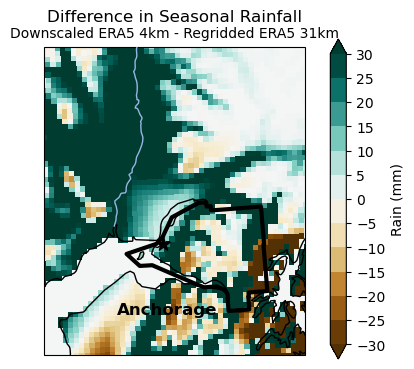

In [ ]:
AK_ALBERS_SUBPLOT_KW = {'projection': ccrs.AlbersEqualArea(
       central_longitude=-154,
       central_latitude=50,
       standard_parallels=(55, 65))}

fig, ax = plt.subplots(subplot_kw=AK_ALBERS_SUBPLOT_KW, figsize=(10, 4))
fig.patch.set_alpha(0)
ax.set_facecolor('none')
levels=np.arange(-30, 35,5)
pcm = ax.pcolormesh(lon, lat, Rain_difference,
   cmap='BrBG',
   vmin=-30, vmax=30,
   shading='auto',
   transform=ccrs.PlateCarree())

cbar = fig.colorbar(pcm, ax=ax, boundaries=levels,label='Rain (mm)',extend='both')
cbar.set_ticks(levels)
cbar.ax.set_position([0.77, 0.1, 0.02, 0.8])

Mun_of_Anc_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=3, zorder=2, transform=ccrs.PlateCarree())
Anchorage_lon = -149.9003
Anchorage_lat = 61.2181
ax.scatter(Anchorage_lon, Anchorage_lat, marker='*', color='black', s=100,zorder=9, transform=ccrs.PlateCarree())
ax.text(Anchorage_lon, Anchorage_lat - 0.5, 'Anchorage', ha='center', va='bottom', fontsize=12,
       fontweight='bold', color='black', zorder=10, transform=ccrs.PlateCarree())

ax.add_feature(cfeature.BORDERS, zorder=9)
ax.add_feature(cfeature.COASTLINE, zorder=9)
ax.add_feature(cfeature.RIVERS, zorder=9)

ax.set_title("Difference in Seasonal Rainfall\n")
ax.text(0.5, 1.03, "Downscaled ERA5 4km - Regridded ERA5 31km", transform=ax.transAxes, fontsize=10, ha='center')

ax.set_extent([-151.5, -148, 60.5, 62.5], crs=ccrs.PlateCarree()) 
ax.set_aspect('equal')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

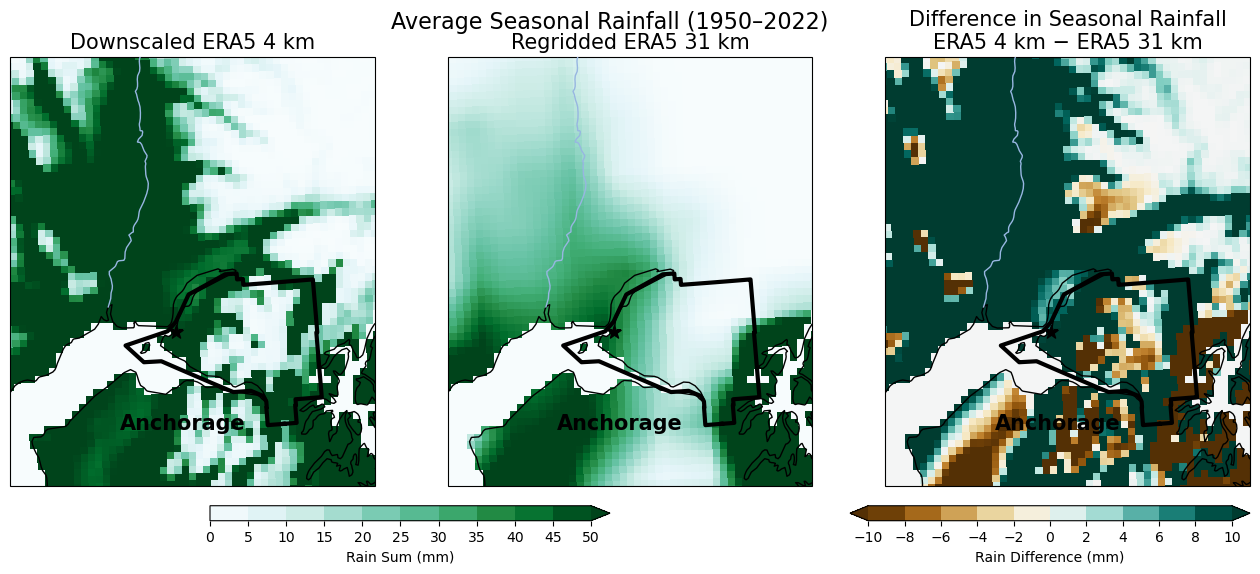

In [ ]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65))
}

fig, axs = plt.subplots(
    nrows=1, ncols=3,
    figsize=(16, 6),
    subplot_kw=AK_ALBERS_SUBPLOT_KW)

cmap_main = 'BuGn'
levels = np.linspace(0, 50, 100)

cmap_diff = 'BrBG'
vmin_diff, vmax_diff = -10, 10

extent = [-151.5, -148, 60.5, 62.5]

Anchorage_lon = -149.9003
Anchorage_lat = 61.2181

pc1 = axs[0].pcolormesh(
    ROS_Rain_seasonal_sum_era5_4km['XLONG'],
    ROS_Rain_seasonal_sum_era5_4km['XLAT'],
    ROS_Rain_seasonal_sum_era5_4km,
    cmap=cmap_main,
    vmin=levels[0], vmax=levels[-1],
    shading='auto',
    transform=ccrs.PlateCarree()
)

axs[0].set_title(
    "Downscaled ERA5 4 km",
    fontsize=15
)

pc2 = axs[1].pcolormesh(
    ROS_RAIN_SUM_nearest_regridded_ERA5_31km['XLONG'],
    ROS_RAIN_SUM_nearest_regridded_ERA5_31km['XLAT'],
    ROS_RAIN_SUM_nearest_regridded_ERA5_31km,
    cmap=cmap_main,
    vmin=levels[0], vmax=levels[-1],
    shading='auto',
    transform=ccrs.PlateCarree()
)

axs[1].set_title(
    "Regridded ERA5 31 km",
    fontsize=15
)

pc3 = axs[2].pcolormesh(
    lon, lat, Rain_difference,
    cmap=cmap_diff,
    vmin=vmin_diff, vmax=vmax_diff,
    shading='auto',
    transform=ccrs.PlateCarree()
)

axs[2].set_title(
    "Difference in Seasonal Rainfall\nERA5 4 km − ERA5 31 km",
    fontsize=15
)

for ax in axs:
    Mun_of_Anc_boundary.plot(
        ax=ax, facecolor='none',
        edgecolor='black', linewidth=3,
        zorder=2, transform=ccrs.PlateCarree()
    )

    ax.scatter(
        Anchorage_lon, Anchorage_lat,
        marker='*', color='black', s=100,
        zorder=9, transform=ccrs.PlateCarree()
    )

    ax.text(
        Anchorage_lon, Anchorage_lat - 0.5,
        'Anchorage',
        ha='center', va='bottom',
        fontsize=15, fontweight='bold',
        zorder=10, transform=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)

    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_aspect('equal')

fig.suptitle("Average Seasonal Rainfall (1950–2022)",fontsize=16, y=0.93)
levels=np.arange(0, 55, 5)
cbar_ax1 = fig.add_axes([0.25, 0.08, 0.25, 0.025])
fig.colorbar(
    pc1,
    cax=cbar_ax1, boundaries=levels,
    orientation='horizontal',
    extend='max',
    label='Rain Sum (mm)',
    ticks=levels
)

# Difference colorbar (panel 3)
levels=np.arange(-10, 12, 2)
cbar_ax2 = fig.add_axes([0.65, 0.08, 0.25, 0.025])
fig.colorbar(
    pc3,
    cax=cbar_ax2,
    orientation='horizontal', boundaries=levels,
    extend='both',
    label='Rain Difference (mm)',
    ticks=levels)

fig.patch.set_alpha(0.0)
plt.show()


Comparing Values to ASOS 


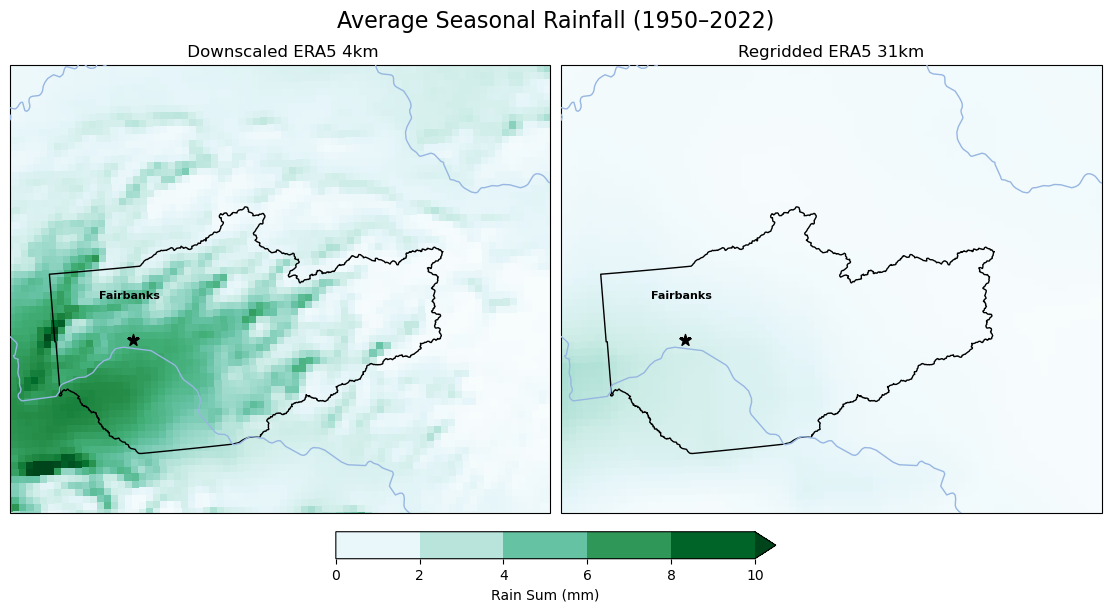

In [8]:
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154, central_latitude=50,
        standard_parallels=(55, 65))}

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(11,9), subplot_kw=AK_ALBERS_SUBPLOT_KW, constrained_layout=True)

# Create color map and levels
cmap = 'BuGn'
levels=np.arange(0, 12, 2)
# Use pcolormesh instead of contourf
pc1 = axs[0].pcolormesh(ROS_Rain_seasonal_sum_era5_4km['XLONG'], ROS_Rain_seasonal_sum_era5_4km['XLAT'], 
                        ROS_Rain_seasonal_sum_era5_4km, 
                        cmap=cmap, 
                        vmin=levels[0], vmax=levels[-1], 
                        shading='auto', transform=ccrs.PlateCarree())

axs[0].set_title(" Downscaled ERA5 4km", fontsize=12)

# Use pcolormesh for ERA5 31km data
pc2 = axs[1].pcolormesh(ROS_RAIN_SUM_nearest_regridded_ERA5_31km['XLONG'], ROS_RAIN_SUM_nearest_regridded_ERA5_31km['XLAT'], 
                        ROS_RAIN_SUM_nearest_regridded_ERA5_31km, 
                        cmap=cmap, 
                        vmin=levels[0], vmax=levels[-1], 
                        shading='auto', transform=ccrs.PlateCarree())
#average seasonal sum of rainfall during ROS events 
#Average Seasonal Rainfall from Winter 1950-2022 
axs[1].set_title("Regridded ERA5 31km", fontsize=12)

for ax in axs:
    FNSB_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, zorder=2, transform=ccrs.PlateCarree())
    ax.scatter(Fairbanks_lon, Fairbanks_lat, marker='*', color='k', s=75, zorder=9, transform=ccrs.PlateCarree())
    ax.text(Fairbanks_lon, Fairbanks_lat + 0.2, 'Fairbanks', ha='center', va='bottom', fontsize=8,
            fontweight='bold', color='black', zorder=6, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-149, -143, 64, 66], crs=ccrs.PlateCarree())
    ax.set_aspect('equal')

#fig.suptitle("Average Hours of Rain on Snow (1950–2022)",fontsize=16, y=0.81)
fig.suptitle("Average Seasonal Rainfall (1950–2022)",fontsize=16, y=0.81)
cbar_ax = fig.add_axes([0.3, 0.20, 0.4, 0.03])
fig.colorbar(pc1,extend='max', cax=cbar_ax,boundaries=levels, orientation='horizontal', label='Rain Sum (mm)', ticks=levels)

fig.patch.set_alpha(0.0)
plt.show()

In [9]:
def getXY(lat, lon, dataarray):
    abslat = np.abs(dataarray.XLAT-lat)
    abslon = np.abs(dataarray.XLONG-lon)
    d = abslon**2 + abslat**2
    flat_index = np.argmin(d.values)
    yloc, xloc = np.unravel_index(flat_index, d.shape)
    return xloc, yloc

In [10]:
Fairbanks_lat=(64.84)
Fairbanks_lon=(-147.72)

anc_lat=(61.2176)
anc_lon=(-149.8997)

bethel_lat=(60.7943)
bethel_lon=(-161.7694)

talkeetna_lat=(62.319)
talkeetna_lon=(-150.09361)

In [11]:
locations = {
    "Fairbanks": {"lat": 64.84, "lon": -147.72},
    "Anchorage": {"lat": 61.2176, "lon": -149.8997},
    "Bethel": {"lat": 60.7943, "lon": -161.7694},
    "Talkeetna": {"lat": 62.319, "lon": -150.09361},
}

In [12]:
for name, coords in locations.items():
    print(f"\n Processing {name}")

    x_idx, y_idx = getXY(
        coords["lat"], coords["lon"], ROS_Rain_seasonal_sum_era5_4km)

    nearest_lat = ROS_Rain_seasonal_sum_era5_4km.XLAT[y_idx, x_idx].values
    nearest_lon = ROS_Rain_seasonal_sum_era5_4km.XLONG[y_idx, x_idx].values
    print(f"Target Coords:  ({coords['lat']}, {coords['lon']})")
    print(f"Nearest Grid:   ({nearest_lat:.4f}, {nearest_lon:.4f})")

    cell4km = ROS_Rain_seasonal_sum_era5_4km.isel(
        south_north=y_idx, west_east=x_idx)
    
    cell31km = ROS_RAIN_SUM_nearest_regridded_ERA5_31km.isel(
        south_north=y_idx, west_east=x_idx)

    val_4km = cell4km.compute()
    val_31km = cell31km.compute()

    print(f"4km Resolution Value:\n{val_4km.values}")
    print(f"31km Resolution Value:\n{val_31km.values}")


 Processing Fairbanks
Target Coords:  (64.84, -147.72)
Nearest Grid:   (64.8241, -147.7343)
4km Resolution Value:
6.155230522155762
31km Resolution Value:
1.9780456504315416

 Processing Anchorage
Target Coords:  (61.2176, -149.8997)
Nearest Grid:   (61.2180, -149.9152)
4km Resolution Value:
54.34410095214844
31km Resolution Value:
42.91919612548988

 Processing Bethel
Target Coords:  (60.7943, -161.7694)
Nearest Grid:   (60.7943, -161.7765)
4km Resolution Value:
35.97804641723633
31km Resolution Value:
31.3778828546247

 Processing Talkeetna
Target Coords:  (62.319, -150.09361)
Nearest Grid:   (62.3260, -150.0591)
4km Resolution Value:
64.12301635742188
31km Resolution Value:
13.306046885415107


In [13]:
season_for_SE_ROS_RAIN_SUM_nearest_regridded_ERA5_31km=np.sum(ERA5_31km_REGRIDDED_ERA5_4km['rain_ros_sum'],axis=(1))
#ROS_RAIN_SUM_nearest_regridded_ERA5_31km=np.mean(ROS_RAIN_SUM_nearest_regridded_ERA5_31km,axis=(0))

season_for_SE_ROS_Rain_sum_era5_4km=np.sum(era5_4km['rain_ros_sum'],axis=1)
#ROS_Rain_seasonal_sum_era5_4km=np.mean(ROS_Rain_sum_era5_4km,axis=0)

In [ ]:
from scipy.stats import sem
import numpy as np

for name, coords in locations.items():

    print(f"\nProcessing {name}")

    x_idx, y_idx = getXY(
        coords["lat"],
        coords["lon"],
        ROS_Rain_seasonal_sum_era5_4km
    )

    # Nearest grid coordinates
    nearest_lat = ROS_Rain_seasonal_sum_era5_4km.XLAT[y_idx, x_idx].values
    nearest_lon = ROS_Rain_seasonal_sum_era5_4km.XLONG[y_idx, x_idx].values

    print(f"Target Coords: ({coords['lat']}, {coords['lon']})")
    print(f"Nearest Grid:  ({nearest_lat:.4f}, {nearest_lon:.4f})")

    # Extract seasonal/yearly time series at this grid cell
    ts_4km = season_for_SE_ROS_Rain_sum_era5_4km[:, y_idx, x_idx]
    ts_31km = season_for_SE_ROS_RAIN_SUM_nearest_regridded_ERA5_31km[:, y_idx, x_idx]

    # Convert Dask/xarray -> NumPy
    ts_4km_np = ts_4km.compute().values
    ts_31km_np = ts_31km.compute().values

    # Mean
    mean_4km = np.mean(ts_4km_np)
    mean_31km = np.mean(ts_31km_np)
    

    # Standard Error
    se_4km = sem(ts_4km_np, ddof=1)
    se_31km = sem(ts_31km_np, ddof=1)
    #STD
    std_4km=np.std(ts_4km_np)
    std_31km=np.std(ts_31km_np)
    
    print(f"4 km:  {mean_4km:.2f} ± {se_4km:.2f}")
    print(f"31 km: {mean_31km:.2f} ± {se_31km:.2f}")
    print(f"std4km: {std_4km}")
    print(f"std31km: {std_31km}")


Processing Fairbanks


Target Coords: (64.84, -147.72)
Nearest Grid:  (64.8241, -147.7343)
4 km:  6.16 ± 0.95
31 km: 1.98 ± 0.50
std4km: 8.049308776855469
std31km: 4.203247638755386

Processing Anchorage
Target Coords: (61.2176, -149.8997)
Nearest Grid:  (61.2180, -149.9152)
4 km:  54.34 ± 3.91
31 km: 42.92 ± 4.56
std4km: 33.15553665161133
std31km: 38.69939505384069

Processing Bethel
Target Coords: (60.7943, -161.7694)
Nearest Grid:  (60.7943, -161.7765)
4 km:  35.98 ± 2.40
31 km: 31.38 ± 2.20
std4km: 20.372974395751953
std31km: 18.630817206648576

Processing Talkeetna
Target Coords: (62.319, -150.09361)
Nearest Grid:  (62.3260, -150.0591)
4 km:  64.12 ± 6.04
31 km: 13.31 ± 1.93
std4km: 51.258094787597656
std31km: 16.385208790883528


In [ ]:
for name, coords in locations.items():

    print(f"\nProcessing {name}")

    x_idx, y_idx = getXY(
        coords["lat"],
        coords["lon"],
        ROS_Rain_seasonal_sum_era5_4km
    )

    # Nearest grid coordinates
    nearest_lat = ROS_Rain_seasonal_sum_era5_4km.XLAT[y_idx, x_idx].values
    nearest_lon = ROS_Rain_seasonal_sum_era5_4km.XLONG[y_idx, x_idx].values

    print(f"Target Coords: ({coords['lat']}, {coords['lon']})")
    print(f"Nearest Grid:  ({nearest_lat:.4f}, {nearest_lon:.4f})")

    # Extract seasonal/yearly time series at this grid cell
    ts_4km = season_for_SE_ROS_Rain_sum_era5_4km[:, y_idx, x_idx]
    ts_31km = season_for_SE_ROS_RAIN_SUM_nearest_regridded_ERA5_31km[:, y_idx, x_idx]

    # Convert Dask/xarray -> NumPy
    ts_4km_np = ts_4km.compute().values
    ts_31km_np = ts_31km.compute().values

    # Mean
    mean_4km = np.mean(ts_4km_np[ts_4km_np != 0])
    mean_31km = np.mean(ts_31km_np[ts_31km_np != 0])
    
    # Standard Error
    se_4km = sem(ts_4km_np, ddof=1)
    se_31km = sem(ts_31km_np, ddof=1)
    #STD
    std_4km=np.std(ts_4km_np)
    std_31km=np.std(ts_31km_np)
    
    print(f"4 km:  {mean_4km:.2f} ± {se_4km:.2f}")
    print(f"31 km: {mean_31km:.2f} ± {se_31km:.2f}")
    print(f"std4km: {std_4km}")
    print(f"std31km: {std_31km}")


Processing Fairbanks
Target Coords: (64.84, -147.72)
Nearest Grid:  (64.8241, -147.7343)
4 km:  7.13 ± 0.95
31 km: 3.07 ± 0.50
std4km: 8.049308776855469
std31km: 4.203247638755386

Processing Anchorage
Target Coords: (61.2176, -149.8997)
Nearest Grid:  (61.2180, -149.9152)
4 km:  54.34 ± 3.91
31 km: 42.92 ± 4.56
std4km: 33.15553665161133
std31km: 38.69939505384069

Processing Bethel
Target Coords: (60.7943, -161.7694)
Nearest Grid:  (60.7943, -161.7765)
4 km:  35.98 ± 2.40
31 km: 31.38 ± 2.20
std4km: 20.372974395751953
std31km: 18.630817206648576

Processing Talkeetna
Target Coords: (62.319, -150.09361)
Nearest Grid:  (62.3260, -150.0591)
4 km:  64.12 ± 6.04
31 km: 13.49 ± 1.93
std4km: 51.258094787597656
std31km: 16.385208790883528
